In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

print("All imports successful ✅")

All imports successful ✅


In [2]:
# Load the preprocessed data saved in Phase 3
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

# Also reload original raw data for feature creation reference
df_raw = pd.read_csv('../data/attrition.csv')

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")

X_train shape: (1972, 44)
X_test shape:  (294, 44)
y_train distribution:
Attrition
0    986
1    986
Name: count, dtype: int64


## Feature Engineering Strategy

Raw features describe facts about employees. Engineered features describe
**relationships and patterns** that raw features don't directly capture.

Our strategy:
1. Create ratio/interaction features (combining two columns into one meaningful signal)
2. Create tenure-based features (how long someone has been in their current situation)
3. Create satisfaction composite features (combining multiple satisfaction scores)
4. Select the most important features (drop noise, keep signal)

In [3]:
df_feat = df_raw.copy()

# ── 1. Income per Year of Experience ────────────────────────────────────────
# Low pay relative to experience is a strong attrition signal
df_feat['IncomePerYearExp'] = (
    df_feat['MonthlyIncome'] / (df_feat['TotalWorkingYears'] + 1)
)

# ── 2. Years Without Promotion ──────────────────────────────────────────────
# Employees stuck without promotion for long tend to leave
df_feat['YearsWithoutPromotion'] = (
    df_feat['YearsAtCompany'] - df_feat['YearsSinceLastPromotion']
)

# ── 3. Satisfaction Score (composite) ───────────────────────────────────────
# Average of all satisfaction-related scores into one signal
df_feat['SatisfactionScore'] = (
    df_feat['JobSatisfaction'] +
    df_feat['EnvironmentSatisfaction'] +
    df_feat['RelationshipSatisfaction'] +
    df_feat['WorkLifeBalance']
) / 4

# ── 4. Manager Loyalty Ratio ─────────────────────────────────────────────────
# How much of their company tenure has been under the same manager
df_feat['ManagerLoyaltyRatio'] = (
    df_feat['YearsWithCurrManager'] / (df_feat['YearsAtCompany'] + 1)
)

# ── 5. Career Growth Rate ────────────────────────────────────────────────────
# How quickly they've progressed (job level relative to total experience)
df_feat['CareerGrowthRate'] = (
    df_feat['JobLevel'] / (df_feat['TotalWorkingYears'] + 1)
)

# ── 6. Is Early Career ───────────────────────────────────────────────────────
# Binary flag — employees in first 2 years leave at much higher rates
df_feat['IsEarlyCareer'] = (df_feat['YearsAtCompany'] <= 2).astype(int)

# ── 7. Is Overdue for Promotion ──────────────────────────────────────────────
# Flag employees who haven't been promoted in 4+ years
df_feat['IsOverduePromotion'] = (df_feat['YearsSinceLastPromotion'] >= 4).astype(int)

new_features = ['IncomePerYearExp', 'YearsWithoutPromotion', 'SatisfactionScore',
                'ManagerLoyaltyRatio', 'CareerGrowthRate', 'IsEarlyCareer', 
                'IsOverduePromotion']

print(f"Created {len(new_features)} new features:")
for f in new_features:
    print(f"  ✅ {f}")

df_feat[new_features].describe().round(3)

Created 7 new features:
  ✅ IncomePerYearExp
  ✅ YearsWithoutPromotion
  ✅ SatisfactionScore
  ✅ ManagerLoyaltyRatio
  ✅ CareerGrowthRate
  ✅ IsEarlyCareer
  ✅ IsOverduePromotion


,IncomePerYearExp,YearsWithoutPromotion,SatisfactionScore,ManagerLoyaltyRatio,CareerGrowthRate,IsEarlyCareer,IsOverduePromotion
count,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000
mean,587.575,4.820,2.731,0.466,0.207,0.233,0.218
std,284.651,4.848,0.506,0.277,0.122,0.423,0.413
min,95.286,0.000,1.000,0.000,0.048,0.000,0.000
25%,374.232,1.000,2.500,0.286,0.125,0.000,0.000
50%,549.221,4.000,2.750,0.500,0.182,0.000,0.000
75%,738.304,7.000,3.000,0.667,0.250,0.000,0.000
max,1904.000,36.000,4.000,0.895,1.000,1.000,1.000


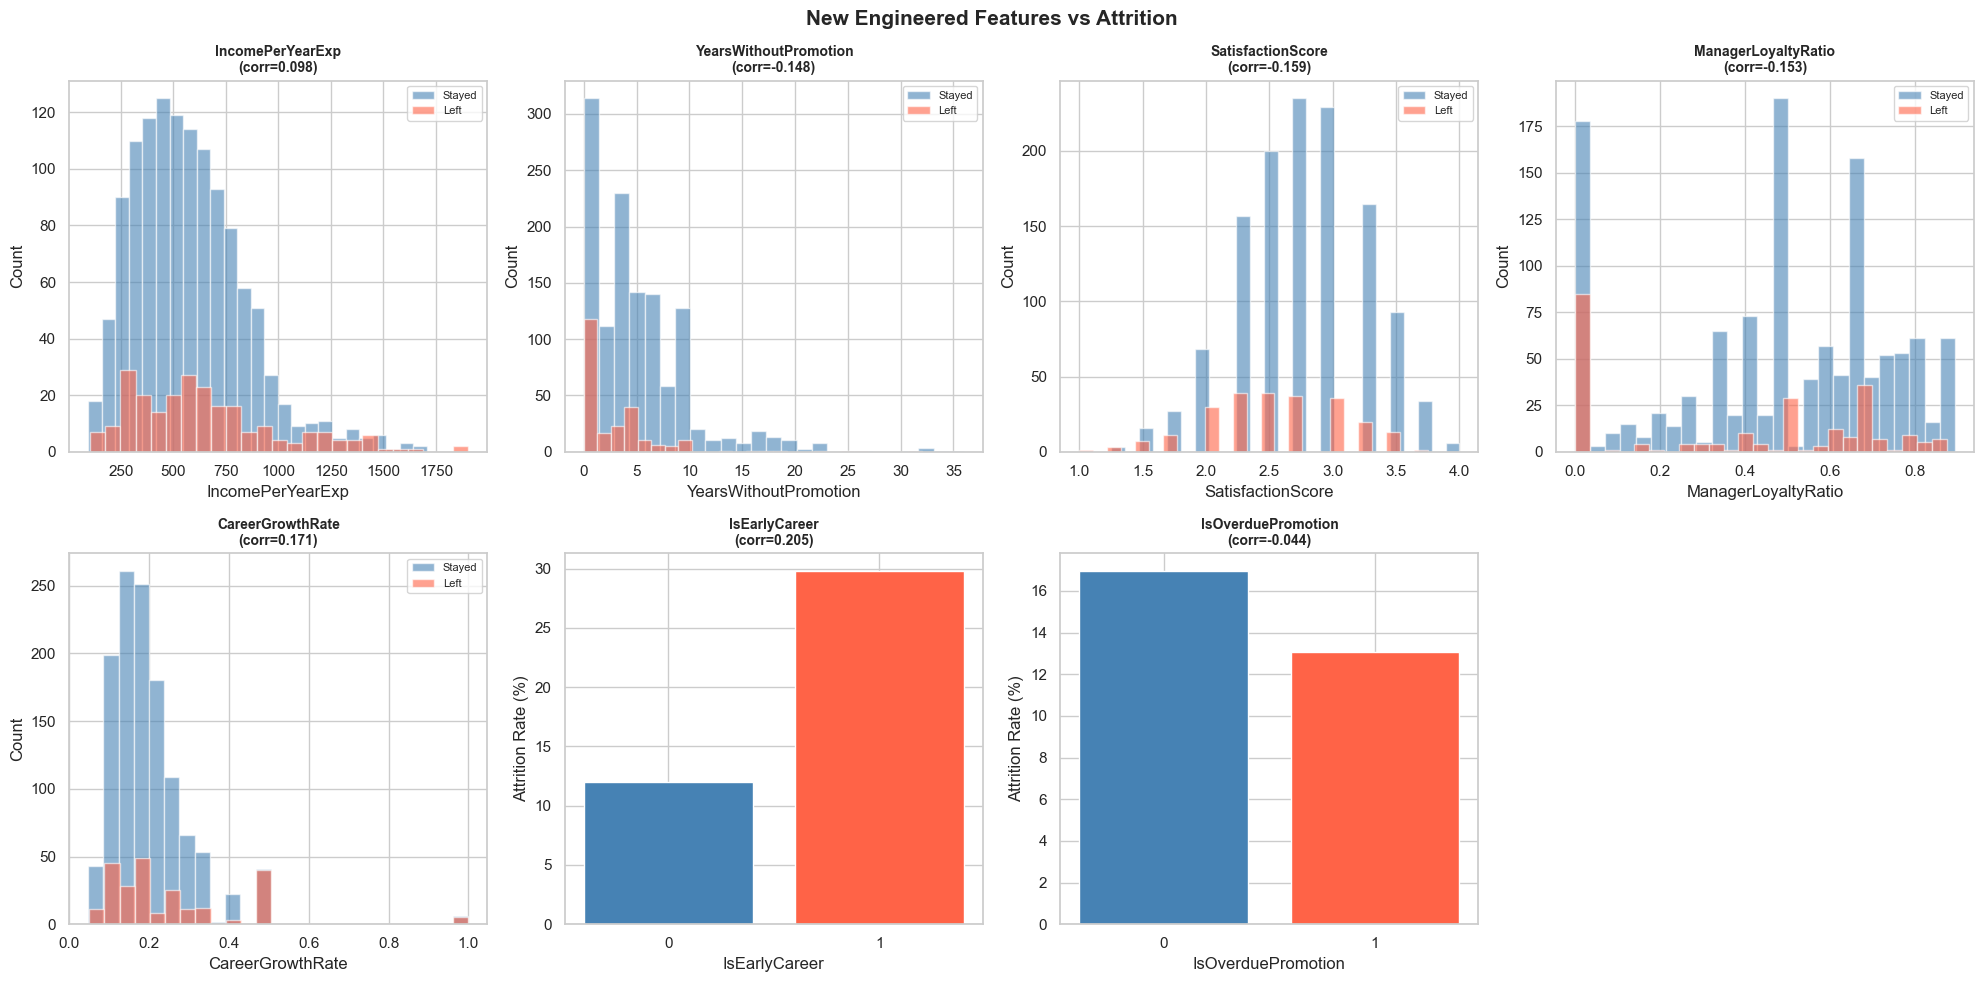

In [4]:
df_feat['Attrition_num'] = (df_feat['Attrition'] == 'Yes').astype(int)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(new_features):
    stayed = df_feat[df_feat['Attrition'] == 'No'][feature]
    left   = df_feat[df_feat['Attrition'] == 'Yes'][feature]

    if df_feat[feature].nunique() == 2:
        # Binary feature → bar chart of attrition rate
        rate = df_feat.groupby(feature)['Attrition_num'].mean() * 100
        axes[i].bar(rate.index.astype(str), rate.values,
                    color=['steelblue', 'tomato'], edgecolor='white')
        axes[i].set_ylabel('Attrition Rate (%)')
    else:
        # Continuous feature → overlapping histogram
        axes[i].hist(stayed, bins=25, alpha=0.6, label='Stayed',
                     color='steelblue', edgecolor='white')
        axes[i].hist(left,   bins=25, alpha=0.6, label='Left',
                     color='tomato',   edgecolor='white')
        axes[i].legend(fontsize=8)
        axes[i].set_ylabel('Count')

    corr = df_feat[feature].corr(df_feat['Attrition_num'])
    axes[i].set_title(f'{feature}\n(corr={corr:.3f})', fontweight='bold', fontsize=10)
    axes[i].set_xlabel(feature)

axes[-1].set_visible(False)

plt.suptitle('New Engineered Features vs Attrition', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# We need to recreate features from the original indices
# Map new features back using the original dataframe index

# First, get the original df with encoding for index alignment
df_encoded = df_raw.copy()
df_encoded['Attrition'] = df_encoded['Attrition'].map({'Yes': 1, 'No': 0})

# Add all engineered features to the encoded df
for feat in new_features:
    df_encoded[feat] = df_feat[feat].values

# Reset index cleanly
df_encoded = df_encoded.reset_index(drop=True)

# Now split the same way Phase 3 did (same random_state=42, stratify)
from sklearn.model_selection import train_test_split

_, _, feat_train_idx, feat_test_idx = train_test_split(
    df_encoded,
    df_encoded.index,
    test_size=0.2,
    random_state=42,
    stratify=df_encoded['Attrition']
)

new_feat_train = df_encoded.loc[feat_train_idx, new_features].reset_index(drop=True)
new_feat_test  = df_encoded.loc[feat_test_idx,  new_features].reset_index(drop=True)

# Add to existing train/test sets
X_train_eng = pd.concat([X_train.reset_index(drop=True), new_feat_train], axis=1)
X_test_eng  = pd.concat([X_test.reset_index(drop=True),  new_feat_test],  axis=1)

print(f"X_train shape before: {X_train.shape}  →  after: {X_train_eng.shape}")
print(f"X_test  shape before: {X_test.shape}   →  after: {X_test_eng.shape}")

X_train shape before: (1972, 44)  →  after: (1972, 51)
X_test  shape before: (294, 44)   →  after: (294, 51)


In [6]:
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_eng, y_train)

importances = pd.Series(
    rf_selector.feature_importances_,
    index=X_train_eng.columns
).sort_values(ascending=False)

print(f"Top 20 most important features:")
print(importances.head(20).round(4))

Top 20 most important features:
SatisfactionScore        0.1621
IncomePerYearExp         0.1337
YearsWithoutPromotion    0.1017
CareerGrowthRate         0.0951
IsOverduePromotion       0.0816
IsEarlyCareer            0.0722
ManagerLoyaltyRatio      0.0553
MonthlyIncome            0.0177
Age                      0.0175
StockOptionLevel         0.0174
TotalWorkingYears        0.0160
DailyRate                0.0139
MonthlyRate              0.0134
DistanceFromHome         0.0128
MaritalStatus_Single     0.0123
HourlyRate               0.0118
OverTime                 0.0116
YearsAtCompany           0.0111
YearsWithCurrManager     0.0109
NumCompaniesWorked       0.0104
dtype: float64


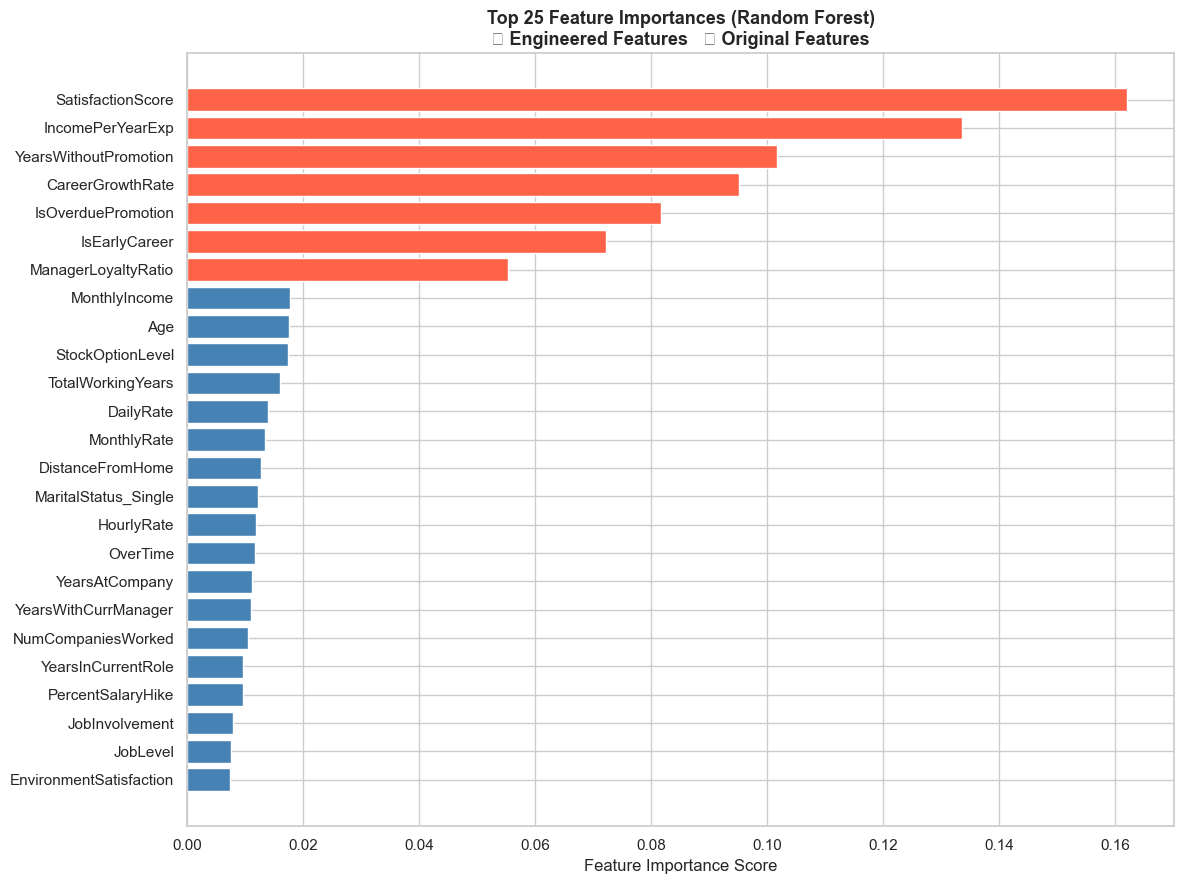

In [7]:
top_n = 25
top_features = importances.head(top_n)

# Color engineered features differently
colors = ['tomato' if f in new_features else 'steelblue' for f in top_features.index]

plt.figure(figsize=(12, 9))
bars = plt.barh(top_features.index[::-1], top_features.values[::-1],
                color=colors[::-1], edgecolor='white')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title(f'Top {top_n} Feature Importances (Random Forest)\n'
          '🔴 Engineered Features   🔵 Original Features',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
TOP_K = 30
selected_features = importances.head(TOP_K).index.tolist()

X_train_final = X_train_eng[selected_features]
X_test_final  = X_test_eng[selected_features]

print(f"Features kept: {TOP_K}")
print(f"Features dropped: {X_train_eng.shape[1] - TOP_K}")
print(f"\nFinal training shape: {X_train_final.shape}")
print(f"Final test shape:     {X_test_final.shape}")
print(f"\nSelected features:\n{selected_features}")

Features kept: 30
Features dropped: 21

Final training shape: (1972, 30)
Final test shape:     (294, 30)

Selected features:
['SatisfactionScore', 'IncomePerYearExp', 'YearsWithoutPromotion', 'CareerGrowthRate', 'IsOverduePromotion', 'IsEarlyCareer', 'ManagerLoyaltyRatio', 'MonthlyIncome', 'Age', 'StockOptionLevel', 'TotalWorkingYears', 'DailyRate', 'MonthlyRate', 'DistanceFromHome', 'MaritalStatus_Single', 'HourlyRate', 'OverTime', 'YearsAtCompany', 'YearsWithCurrManager', 'NumCompaniesWorked', 'YearsInCurrentRole', 'PercentSalaryHike', 'JobInvolvement', 'JobLevel', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobRole_Laboratory Technician', 'TrainingTimesLastYear', 'JobSatisfaction', 'Education']


In [9]:
# Save final feature sets
X_train_final.to_csv('../data/X_train_final.csv', index=False)
X_test_final.to_csv('../data/X_test_final.csv',   index=False)

# Save selected feature names and engineered feature names
with open('../models/selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

with open('../models/engineered_feature_names.pkl', 'wb') as f:
    pickle.dump(new_features, f)

print("Saved successfully:")
print("  ✅ data/X_train_final.csv")
print("  ✅ data/X_test_final.csv")
print("  ✅ models/selected_features.pkl")
print("  ✅ models/engineered_feature_names.pkl")

Saved successfully:
  ✅ data/X_train_final.csv
  ✅ data/X_test_final.csv
  ✅ models/selected_features.pkl
  ✅ models/engineered_feature_names.pkl


## Feature Engineering Summary

### New Features Created (7)
| Feature | Logic | Rationale |
|---|---|---|
| IncomePerYearExp | MonthlyIncome / (TotalWorkingYears+1) | Underpaid for experience → leave |
| YearsWithoutPromotion | YearsAtCompany - YearsSinceLastPromotion | Career stagnation → leave |
| SatisfactionScore | Mean of 4 satisfaction columns | Composite wellbeing signal |
| ManagerLoyaltyRatio | YearsWithCurrManager / (YearsAtCompany+1) | Manager relationship stability |
| CareerGrowthRate | JobLevel / (TotalWorkingYears+1) | Progression speed |
| IsEarlyCareer | YearsAtCompany <= 2 | First 2 years = highest risk |
| IsOverduePromotion | YearsSinceLastPromotion >= 4 | Promotion frustration flag |

### Feature Selection
- Started with: all original + 7 engineered features
- Kept top 30 by Random Forest importance score
- Dropped low-signal features to reduce noise